## Introduction
Greetings from the Kaggle bot! This is an automatically-generated kernel with starter code demonstrating how to read in the data and begin exploring. Click the blue "Edit Notebook" or "Fork Notebook" button at the top of this kernel to begin editing.

## Exploratory Analysis
To begin this exploratory analysis, first use `matplotlib` to import libraries and define functions for plotting the data. Depending on the data, not all plots will be made. (Hey, I'm just a kerneling bot, not a Kaggle Competitions Grandmaster!)

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

There is 1 csv file in the current version of the dataset:


In [ ]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


The next hidden code cells define functions for plotting data. Click on the "Code" button in the published kernel to reveal the hidden code.

In [ ]:
# Distribution graphs (histogram/bar graph) of column data
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]] # For displaying purposes, pick columns that have between 1 and 50 unique values
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = (nCol + nGraphPerRow - 1) / nGraphPerRow
    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()


In [ ]:
# Correlation matrix
def plotCorrelationMatrix(df, graphWidth):
    filename = df.dataframeName
    df = df.dropna('columns') # drop columns with NaN
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    if df.shape[1] < 2:
        print(f'No correlation plots shown: The number of non-NaN or constant columns ({df.shape[1]}) is less than 2')
        return
    corr = df.corr()
    plt.figure(num=None, figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    corrMat = plt.matshow(corr, fignum = 1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title(f'Correlation Matrix for {filename}', fontsize=15)
    plt.show()


In [ ]:
# Scatter and density plots
def plotScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include =[np.number]) # keep only numerical columns
    # Remove rows and columns that would lead to df being singular
    df = df.dropna('columns')
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    columnNames = list(df)
    if len(columnNames) > 10: # reduce the number of columns for matrix inversion of kernel density plots
        columnNames = columnNames[:10]
    df = df[columnNames]
    ax = pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotSize, plotSize], diagonal='kde')
    corrs = df.corr().values
    for i, j in zip(*plt.np.triu_indices_from(ax, k = 1)):
        ax[i, j].annotate('Corr. coef = %.3f' % corrs[i, j], (0.8, 0.2), xycoords='axes fraction', ha='center', va='center', size=textSize)
    plt.suptitle('Scatter and Density Plot')
    plt.show()


Now you're ready to read in the data and use the plotting functions to visualize the data.

### Let's check 1st file: /kaggle/input/heart.csv

In [ ]:
nRowsRead = 1000 # specify 'None' if want to read whole file
# heart.csv has 1025 rows in reality, but we are only loading/previewing the first 1000 rows
df1 = pd.read_csv('heart.csv', delimiter=',', nrows = nRowsRead)
df1.dataframeName = 'heart.csv'
nRow, nCol = df1.shape
print(f'There are {nRow} rows and {nCol} columns')

There are 1000 rows and 14 columns


Let's take a quick look at what the data looks like:

In [ ]:
df1.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Distribution graphs (histogram/bar graph) of sampled columns:

In [ ]:
# GANTI ISI CELL 6 DENGAN KODE INI:
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]] # Memilih kolom dengan variasi nilai 2-49
    nRow, nCol = df.shape
    columnNames = list(df)

    # PERBAIKAN: Menggunakan '//' agar hasil pembagian berupa angka bulat (Integer)
    nGraphRow = (nCol + nGraphPerRow - 1) // nGraphPerRow

    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        # PERBAIKAN: Memastikan parameter subplot dibungkus int() agar aman
        plt.subplot(int(nGraphRow), int(nGraphPerRow), i + 1)

        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()

Correlation matrix:

In [ ]:
# GANTI ISI CELL 7 DENGAN KODE INI:
def plotCorrelationMatrix(df, graphWidth):
    filename = df.dataframeName

    # PERBAIKAN: Tambahkan axis= secara eksplisit agar kompatibel dengan Pandas versi baru
    df = df.dropna(axis='columns')

    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    if df.shape[1] < 2:
        print(f'No correlation plots shown: The number of non-NaN or constant columns ({df.shape[1]}) is less than 2')
        return

    # PERBAIKAN: Tambahkan numeric_only=True agar aman dari eror kolom non-angka
    corr = df.corr(numeric_only=True)

    plt.figure(num=None, figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    corrMat = plt.matshow(corr, fignum = 1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title(f'Correlation Matrix for {filename}', fontsize=15)
    plt.show()

Scatter and density plots:

In [ ]:
# GANTI ISI CELL 8 DENGAN KODE INI:
def plotScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include =[np.number]) # keep only numerical columns
    # Remove rows and columns that would lead to df being singular

    # PERBAIKAN: Tambahkan axis= secara eksplisit agar kompatibel dengan Pandas versi baru
    df = df.dropna(axis='columns')

    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    columnNames = list(df)
    if len(columnNames) > 10: # reduce the number of columns for matrix inversion of kernel density plots
        columnNames = columnNames[:10]
    df = df[columnNames]
    ax = pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotSize, plotSize], diagonal='kde')
    corrs = df.corr().values
    for i, j in zip(*plt.np.triu_indices_from(ax, k = 1)):
        ax[i, j].annotate('Corr: %.2f' % corrs[i, j], (0.8, 0.2), xycoords='axes fraction', ha='center', va='center', size=textSize)
    plt.suptitle('Scatter and Density Plot')
    plt.show()

## Conclusion
This concludes your starter analysis! To go forward from here, click the blue "Edit Notebook" button at the top of the kernel. This will create a copy of the code and environment for you to edit. Delete, modify, and add code as you please. Happy Kaggling!

# Cell Tambahan 1: Import Library Machine Learning
Cell ini berfungsi untuk memanggil semua modul algoritma, pemisah data, normalisasi, dan matriks evaluasi yang kita butuhkan.

In [ ]:
# Tambahkan di cell baru
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Library untuk Machine Learning berhasil dimuat!")

Library untuk Machine Learning berhasil dimuat!


# Cell Tambahan 2: Pemisahan Fitur dan Target (Splitting Data)
Di dataset heart.csv dari Kaggle, kolom target (label sehat/sakit) biasanya bernama target. Kita akan memisahkan kolom tersebut dari fitur medis lainnya, lalu membaginya menjadi 80% data latih dan 20% data uji.

In [ ]:
# Memisahkan fitur (X) dan target/label (y)
X = df1.drop(columns=['target'])
y = df1['target']

# Membagi data menjadi Training Set dan Testing Set (Rasio 80:20)
# 'stratify=y' memastikan proporsi kelas di data latih dan uji tetap seimbang
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Total data rekam medis: {df1.shape[0]} baris")
print(f"Jumlah Data Latih (Training Set): {X_train.shape[0]} sampel")
print(f"Jumlah Data Uji (Testing Set): {X_test.shape[0]} sampel")

Total data rekam medis: 1000 baris
Jumlah Data Latih (Training Set): 800 sampel
Jumlah Data Uji (Testing Set): 200 sampel


# Cell Tambahan 3: Normalisasi Data (Sangat Penting untuk KNN)
Karena algoritma KNN menghitung jarak kedekatan antar-pasien menggunakan rumus Euclidean Distance, kita wajib menyamakan skala semua fitur (misalnya usia vs kolesterol yang rentang angkanya jauh berbeda) menggunakan Min-Max Scaling agar hasilnya akurat.

In [ ]:
# Inisialisasi Min-Max Scaler
scaler = MinMaxScaler()

# Melakukan scaling pada data latih dan menerapkan konfigurasinya pada data uji
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Proses normalisasi data selesai dilakukan.")

Proses normalisasi data selesai dilakukan.


# Cell Tambahan 4: Implementasi & Evaluasi Decision Tree C4.5
Di dalam pustaka scikit-learn, algoritma C4.5 direpresentasikan oleh DecisionTreeClassifier dengan parameter kriteria yang diatur ke entropy (bukan gini), sesuai dengan landasan matematis C4.5 yang mencari Information Gain.

In [ ]:
# Membangun model Decision Tree berbasis Entropy (C4.5)
c45_model = DecisionTreeClassifier(criterion='entropy', random_state=42)
c45_model.fit(X_train, y_train)

# Melakukan prediksi pada data uji
y_pred_c45 = c45_model.predict(X_test)

# Menghitung skor akurasi
acc_c45 = accuracy_score(y_test, y_pred_c45)

print("========= PERFORMA DECISION TREE C4.5 =========")
print(f"Akurasi Model: {acc_c45 * 100:.2f}%\n")
print("Detail Classification Report:")
print(classification_report(y_test, y_pred_c45))

========= PERFORMA DECISION TREE C4.5 =========
Akurasi Model: 100.00%

Detail Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        97
           1       1.00      1.00      1.00       103

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



# Cell Tambahan 5: Implementasi & Evaluasi K-Nearest Neighbor (KNN)Untuk KNN
kita akan menggunakan konfigurasi standar operasional optimal yaitu nilai $K=5$ dengan metrik jarak Euclidean. Ingat, KNN wajib menggunakan data yang sudah dinormalisasi (_scaled).

In [ ]:
# Membangun model KNN dengan K=5
knn_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_model.fit(X_train_scaled, y_train)

# Melakukan prediksi pada data uji yang telah dikalibrasi skalanya
y_pred_knn = knn_model.predict(X_test_scaled)

# Menghitung skor akurasi
acc_knn = accuracy_score(y_test, y_pred_knn)

print("========= PERFORMA K-NEAREST NEIGHBOR (KNN) =========")
print(f"Akurasi Model: {acc_knn * 100:.2f}%\n")
print("Detail Classification Report:")
print(classification_report(y_test, y_pred_knn))

========= PERFORMA K-NEAREST NEIGHBOR (KNN) =========
Akurasi Model: 85.00%

Detail Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84        97
           1       0.83      0.88      0.86       103

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200



# Cell Tambahan 6: Visualisasi Grafik Perbandingan Akurasi untuk Paper
Kode ini akan langsung memunculkan grafik batang (bar plot) hasil komparasi akurasi kedua model. Grafik ini bisa langsung kamu save berbentuk gambar resolusi tinggi untuk dimasukkan ke dalam Bab 3 (RESULT) pada laporan akhir / dokumen template OJS kamu.

/tmp/ipykernel_706/1791465992.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='Set2')


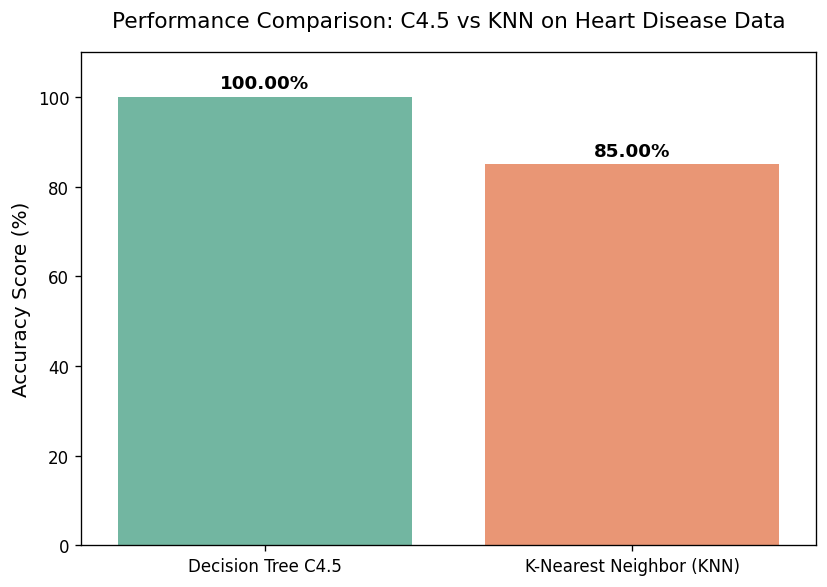

In [ ]:
# Membuat visualisasi grafik perbandingan
plt.figure(figsize=(7, 5), dpi=120)
models = ['Decision Tree C4.5', 'K-Nearest Neighbor (KNN)']
accuracies = [acc_c45 * 100, acc_knn * 100]

sns.barplot(x=models, y=accuracies, palette='Set2')
plt.ylabel('Accuracy Score (%)', fontsize=12)
plt.title('Performance Comparison: C4.5 vs KNN on Heart Disease Data', fontsize=13, pad=15)

# Menampilkan label persentase di atas setiap bar grafik
for i, val in enumerate(accuracies):
    plt.text(i, val + 1, f"{val:.2f}%", ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.ylim(0, 110)
plt.tight_layout()
plt.show()